# Panel Gauss–Legendre n-modes

The production n-mode integrator (`INSPECTRE_INTEG_PANEL_GL`, mode 6,
`src/inspectre_lib.c`) computes the Fourier amplitudes

$$X_n = \frac{1}{T_r}\int_0^{T_r} X_m(t)\, e^{i\omega_{mn} t}\,dt
      = \frac{1}{T_r}\int_0^{\Lambda_r} X_m(\lambda)\,
        e^{i\omega_{mn} t(\lambda)}\,\frac{dt}{d\lambda}\,d\lambda$$

where $\omega_{mn} = m\Omega_\phi + n\Omega_r$ and $X_m \in \{\Phi^S_{m}, \partial_\mu\Phi^S_{m},
S_{{\rm eff},m}\}$ of the m-mode effective-source data, from **one node set per
field point** reused for every $n$.

This notebook rebuilds that method in pure Python, one ingredient at a time,
using only the single-point evaluator `eval_at_lambda_fast` (the m-mode
timeseries data) and the analytic orbit functions:

1. the **raw timeseries** $X_m(\lambda)$ and why it is hard to integrate;
2. **naive quadrature** (uniform trapezoid / uniform-panel GL) and where it stalls;
3. **analytic breakpoints**, the closest-approach Mino times, in closed form;
4. the **geometric panel stack** into each breakpoint;
5. the **oscillation subdivision** that caps the usable $|n|$;
6. **assembly**, Gauss–Legendre weights, Jacobian, phase sum;
7. **validation**, node-for-node and value-for-value against the C
   implementation, and both against an adaptive QAG reference.

The companion notebook `panel_method_visualization.ipynb` explores the node
*geometry* the C code produces; here we re-derive the construction itself.
All panel structure lives on the Mino-time axis $\lambda$ (breakpoints are
analytic there), so x-axes below are $\lambda/\Lambda_r$.

In [1]:
import sys, os, math, time
for rel in ('..', '../../effectivesource', '../../kerrgeodesic'):
    sys.path.insert(0, os.path.abspath(rel))
import numpy as np
import matplotlib.pyplot as plt
from inspectre.inspectre import Inspectre
import inspectre_c as c
import kerrgeodesics as kg

# palette (validated): blue = data/nodes, green = orbit, yellow = breakpoints
BLUE, GREEN, YELLOW = '#2a78d6', '#008300', '#eda100'
INK, MUTE = '#222222', '#888888'
PANEL_A, PANEL_B = '#00000012', '#00000004'
plt.rcParams.update({'axes.grid': True, 'grid.alpha': 0.15,
                     'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110})

a, p, e, M = 0.5, 10.0, 0.3, 2
insp = Inspectre(spin=a, semilatus_rectum=p, eccentricity=e)
orbit = insp._orbpar                      # raw korb_params handle
Vr = insp.mino_period_r               # Mino-time radial period Lambda_r
Tr = insp.t_from_lambda(Vr)           # coordinate-time radial period T_r
om_r, om_ph = insp.omega_r, insp.omega_phi
rmin, rmax = p/(1+e), p/(1-e)

r_near  = p/(1+0.5*e)                 # inside libration range -> 2 breakpoints
th_near = np.pi/2 + 0.01              # slightly off-equator (finite peak)
r_out   = rmax + 2.0                  # outside libration range -> 1 breakpoint

# analytic orbit helpers (same korb_* calls the C code makes)
def r_from_lam(lam):
    return kg.korb_rfrompsi(kg.korb_psifromla(lam, orbit), orbit)

def t_from_lam(lam):
    return kg.korb_tfromla(lam, orbit)

def dtdlam(lam):
    '''Jacobian dt/dlambda = T_r(psi) + T_th(chi)  (insp_dtdlambda).'''
    return (kg.korb_Tr(kg.korb_psifromla(lam, orbit), orbit)
            + kg.korb_Tth(kg.korb_chifromla(lam, orbit), orbit))

def eval6(m, lam, r_f, th_f):
    '''The m-mode timeseries sampler: 6 complex components at Mino time lam.
    [PhiS, dPhiS_t, dPhiS_r, dPhiS_th, dPhiS_ph, src]'''
    P, dP, dd, S = insp.eval_at_lambda_fast(m, float(lam), r_f, th_f)
    v = np.empty(6, complex)
    v[0] = P[0] + 1j*P[1]
    for k in range(4):
        v[1+k] = dP[2*k] + 1j*dP[2*k+1]
    v[5] = S[0] + 1j*S[1]
    return v

COMP = ['PhiS', 'dPhiS_t', 'dPhiS_r', 'dPhiS_th', 'dPhiS_ph', 'src']

# C node-set access (as in panel_method_visualization.ipynb)
def arr(ptr, n):
    A = c.doubleArray.frompointer(ptr)
    return np.array([A[i] for i in range(n)])

def build_nodes_c(m, nMax, r_f, th_f, order=16, max_levels=40):
    xF = insp.es.make_coordinate(0.0, r_f, th_f, 0.0)
    s = c.panel_nodes_build(insp._ctx, m, xF, insp._orbpar, a, p, e,
                            insp.omega_phi, insp.omega_r,
                            order=order, maxLevels=max_levels, nMax=nMax)
    N = s.n
    return dict(N=N, order=order, nBreak=s.nBreak, nNonFinite=s.nNonFinite,
                lamBreak=arr(s.lamBreak, 2)[:s.nBreak],
                dlam=arr(s.dlam, 2)[:s.nBreak],
                lam=arr(s.lam, N), t=arr(s.t, N), J=arr(s.J, N),
                w=arr(s.w, N), _s=s)

def integrate_c(R, m, n):
    P, dP, S = c.panel_nodes_integrate(R['_s'], m, int(n), om_ph, om_r)
    v = np.empty(6, complex)
    v[0] = P[0] + 1j*P[1]
    for k in range(4):
        v[1+k] = dP[2*k] + 1j*dP[2*k+1]
    v[5] = S[0] + 1j*S[1]
    return v

print(f'Tr={Tr:.3f}  Vr={Vr:.5f}  om_r={om_r:.6f}  om_ph={om_ph:.6f}')
print(f'r_min={rmin:.4f}  r_max={rmax:.4f}  r_near={r_near:.4f}  r_out={r_out:.4f}')

Tr=313.403  Vr=2.35193  om_r=0.020048  om_ph=0.027881
r_min=7.6923  r_max=14.2857  r_near=8.6957  r_out=16.2857


## 1. The raw data: the m-mode timeseries

The $n$-mode integration takes in the m-mode effective-source data sampled
along the orbit: at each Mino time $\lambda$ the particle sits at
$r_p(\lambda)$ and the evaluator returns the six complex components at the
fixed field point. The magnitude is sharply peaked at the **closest-approach
passages**, the two times per radial period when $r_p$ crosses the field
point's radius (the puncture $\sim 1/\text{distance}$), and the integrand
additionally carries the $e^{i\omega_{mn}t}$ Fourier phase which oscillates
faster as $|n|$ grows. Those two features (a near-singular peak + a fast
carrier) are the whole difficulty.

1200 timeseries samples in 6.6 s (5.51 ms/sample)


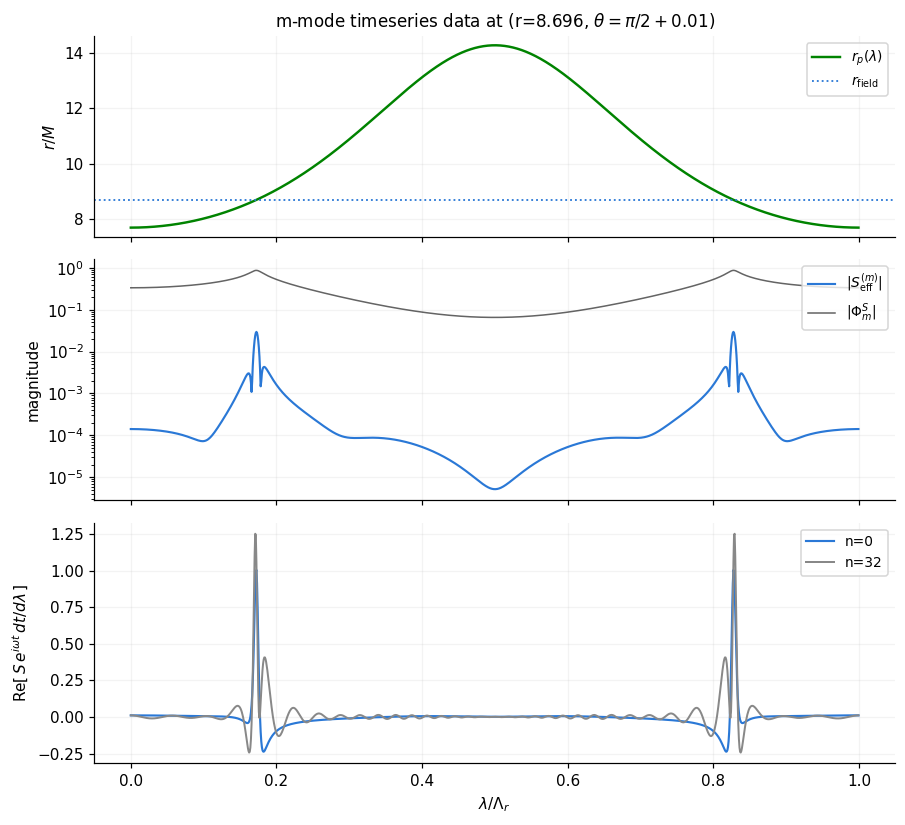

In [4]:
r_f, th_f = r_near, th_near
NLAM = 1200
lam_d = np.linspace(0.0, Vr, NLAM, endpoint=False)
t_d = np.array([t_from_lam(l) for l in lam_d])
J_d = np.array([dtdlam(l) for l in lam_d])
r_d = np.array([r_from_lam(l) for l in lam_d])
t0 = time.perf_counter()
V_d = np.array([eval6(M, l, r_f, th_f) for l in lam_d])   # (NLAM, 6)
t_dense = time.perf_counter() - t0
print(f'{NLAM} timeseries samples in {t_dense:.1f} s '
      f'({1e3*t_dense/NLAM:.2f} ms/sample)')

x = lam_d / Vr
fig, axs = plt.subplots(3, 1, figsize=(8.2, 7.6), sharex=True,
                        gridspec_kw={'height_ratios': [1, 1.2, 1.2]})
ax = axs[0]
ax.plot(x, r_d, color=GREEN, lw=1.6, label=r'$r_p(\lambda)$')
ax.axhline(r_f, color=BLUE, lw=1.2, ls=':', label=r'$r_{\rm field}$')
ax.set_ylabel(r'$r/M$'); ax.legend(loc='upper right', fontsize=9)
ax.set_title(f'm-mode timeseries data at (r={r_f:.3f}, '
             r'$\theta=\pi/2+0.01$)', fontsize=11)

ax = axs[1]
ax.semilogy(x, np.abs(V_d[:, 5]), color=BLUE, lw=1.4,
            label=r'$|S_{\rm eff}^{(m)}|$')
ax.semilogy(x, np.abs(V_d[:, 0]), color=INK, lw=1.0, alpha=0.7,
            label=r'$|\Phi^S_m|$')
ax.set_ylabel('magnitude'); ax.legend(loc='upper right', fontsize=9)

ax = axs[2]
for n_, col, lw_ in ((0, BLUE, 1.4), (32, MUTE, 1.3)):
    ph = np.exp(1j*(M*om_ph + n_*om_r)*t_d)
    ax.plot(x, (V_d[:, 5]*ph*J_d).real, color=col, lw=lw_, label=f'n={n_}')
ax.set_ylabel(r'Re$[\,S\,e^{i\omega t}\,dt/d\lambda\,]$')
ax.set_xlabel(r'$\lambda/\Lambda_r$'); ax.legend(loc='upper right', fontsize=9)
plt.tight_layout()

## 2. Naive quadrature and where it stalls

The integrand is smooth and periodic, so a uniform trapezoid rule (a Riemann
sum on a periodic function) is *eventually* spectrally accurate, but only
once the grid resolves the closest-approach peak, whose $\lambda$-scale
shrinks in proportion to the field point's distance from the orbit ($\to 0$ on
the orbit itself). Until then convergence stalls, so the uniform-grid cost is
$N \sim \Lambda_r/d\lambda_{\rm peak} \propto 1/\text{distance}$. A
uniform-panel Gauss–Legendre rule does no better. 
The experiment below shows the same integral at two
polar offsets, $\theta = \pi/2 + 0.01$ and $\pi/2 + 0.001$. Moving ten times closer
costs the uniform rules ten times the nodes, while the panel method (shown with stars) 
pays only $\log_2 10 \approx 3$ extra panels per breakpoint.

The reference data at the farther point is the adaptive QAG integrator over Mino time
(`INSPECTRE_INTEG_QAG_MINO`) at $10^{-13}$ tolerance. Accurate but expensive,
it re-adapts hundreds of fresh evaluations for every single $(m,n)$.
At the closer point, where QAG itself struggles, a high-resolution panel rule
(order 44, 54 levels) serves as reference.

In [5]:
ic = c
def qag_ref(m, n, r_f, th_f):
    t0 = time.perf_counter()
    P, dP, S = insp.integrate_nmode_fast(
        m, int(n), r_f, th_f, mode=c.INSPECTRE_INTEG_QAG_MINO,
        epsabs=1e-13, epsrel=1e-13)
    dt = time.perf_counter() - t0
    v = np.empty(6, complex)
    v[0] = P[0] + 1j*P[1]
    for k in range(4):
        v[1+k] = dP[2*k] + 1j*dP[2*k+1]
    v[5] = S[0] + 1j*S[1]
    return v, dt

REF = {}
for (rf_, thf_, tag) in ((r_near, th_near, 'near'), (r_out, np.pi/2, 'out')):
    for n_ in (0, 8):
        REF[tag, n_], dt = qag_ref(M, n_, rf_, thf_)
        print(f'QAG_MINO ref {tag:>4s} n={n_:2d}: '
              f'src = {REF[tag, n_][5]:+.9e}   ({dt:.1f} s)')

QAG_MINO ref near n= 0: src = +3.088531032e-06+4.929582635e-14j   (44.9 s)
QAG_MINO ref near n= 8: src = -1.370874598e-04+4.108084743e-14j   (53.1 s)
QAG_MINO ref  out n= 0: src = -2.198688808e-05-1.628385884e-16j   (7.7 s)
QAG_MINO ref  out n= 8: src = +2.830057922e-06+1.594072042e-16j   (15.6 s)


panel rule: N=384 err=2.8e-10 at +0.01;  N=576 err=1.4e-09 at +0.001


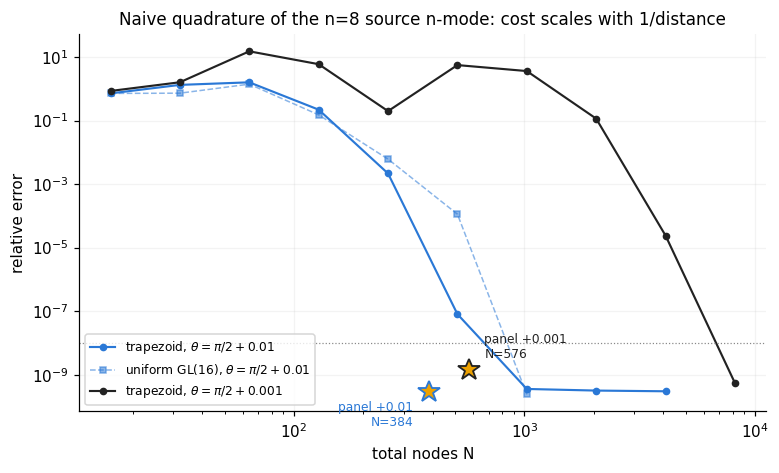

In [6]:
# naive rules for the n=8 source n-mode, two polar offsets
n_show = 8
om_mn = M*om_ph + n_show*om_r
th_close = np.pi/2 + 0.001

def trap_errs(th_f, ref_val, ndense):
    '''Uniform trapezoid errors by subsampling one dense periodic grid.'''
    lam_u = np.linspace(0.0, Vr, ndense, endpoint=False)
    g = np.array([eval6(M, l, r_near, th_f)[5]
                  * np.exp(1j*om_mn*t_from_lam(l)) * dtdlam(l)
                  for l in lam_u])
    Ns, errs = [], []
    k = 16
    while k <= ndense:
        val = g[::ndense//k].sum() * (Vr/k) / Tr
        Ns.append(k); errs.append(abs(val - ref_val)/abs(ref_val))
        k *= 2
    return Ns, errs

def panel_point(th_f, ref_val):
    '''(node count, error) of the production panel rule at this offset.'''
    R = build_nodes_c(M, n_show, r_near, th_f, order=16, max_levels=40)
    err = abs(integrate_c(R, M, n_show)[5] - ref_val)/abs(ref_val)
    N = R['N']; c.panel_nodes_free(R['_s'])
    return N, err

# references: QAG at th=+0.01; high-res panel at th=+0.001 (QAG struggles there)
ref_far = REF['near', n_show][5]
R_hi = build_nodes_c(M, n_show, r_near, th_close, order=44, max_levels=54)
ref_close = integrate_c(R_hi, M, n_show)[5]
c.panel_nodes_free(R_hi['_s'])

trapF_N, trapF_e = trap_errs(th_near, ref_far, 4096)
trapC_N, trapC_e = trap_errs(th_close, ref_close, 8192)

# uniform-panel GL(16) at th=+0.01: fresh evaluations
xi, wq = np.polynomial.legendre.leggauss(16)
gl_N, gl_err = [], []
for npan in (1, 2, 4, 8, 16, 32, 64):
    edges = np.linspace(0.0, Vr, npan+1)
    tot = 0.0+0.0j
    for pa_, pb_ in zip(edges[:-1], edges[1:]):
        lamj = 0.5*(pa_+pb_) + 0.5*(pb_-pa_)*xi
        wj = 0.5*(pb_-pa_)*wq
        for l, w_ in zip(lamj, wj):
            tot += w_ * eval6(M, l, r_near, th_near)[5] \
                     * np.exp(1j*om_mn*t_from_lam(l)) * dtdlam(l)
    gl_N.append(16*npan); gl_err.append(abs(tot/Tr - ref_far)/abs(ref_far))

panF = panel_point(th_near, ref_far)
panC = panel_point(th_close, ref_close)

fig, ax = plt.subplots(figsize=(7.2, 4.4))
ax.loglog(trapF_N, trapF_e, 'o-', color=BLUE, lw=1.4, ms=4,
          label=r'trapezoid, $\theta=\pi/2+0.01$')
ax.loglog(gl_N, gl_err, 's--', color=BLUE, lw=1.0, ms=4, alpha=0.55,
          label=r'uniform GL(16), $\theta=\pi/2+0.01$')
ax.loglog(trapC_N, trapC_e, 'o-', color=INK, lw=1.4, ms=4,
          label=r'trapezoid, $\theta=\pi/2+0.001$')
for (N_, e_), col, tag, (dx, dy, ha) in (
        (panF, BLUE, '+0.01', (-10, -22, 'right')),
        (panC, INK, '+0.001', (10, 8, 'left'))):
    ax.plot(N_, max(e_, 1e-12), '*', color=YELLOW, ms=15,
            markeredgecolor=col, markeredgewidth=1.2, zorder=5)
    ax.annotate(f'panel {tag}\nN={N_}', (N_, max(e_, 1e-12)), fontsize=8,
                color=col, ha=ha, xytext=(dx, dy),
                textcoords='offset points')
ax.axhline(1e-8, color=MUTE, lw=0.8, ls=':')
ax.set_xlabel('total nodes N'); ax.set_ylabel('relative error')
ax.set_title(f'Naive quadrature of the n={n_show} source n-mode: '
             'cost scales with 1/distance', fontsize=11)
ax.legend(fontsize=8, loc='lower left')
plt.tight_layout()
print(f'panel rule: N={panF[0]} err={panF[1]:.1e} at +0.01;  '
      f'N={panC[0]} err={panC[1]:.1e} at +0.001')

## 3. Ingredient 1: analytic breakpoints

The peaks sit exactly where the particle passes
closest to the field point. With $r_p = p/(1+e\cos\psi)$, the radial phase of
closest approach to a field radius $r_f$ inside the libration range is

$$\psi_c = \arccos\!\Big(\frac{p/r_f - 1}{e}\Big),$$

giving **two** breakpoints per period, $\lambda_{c1} = \lambda(\psi_c)$
(outbound) and $\lambda_{c2} = \Lambda_r - \lambda_{c1}$ (inbound), by the
time-symmetry of the radial motion. Outside the libration range there is a single breakpoint
at the nearest turning point. $\lambda(\psi_c)$
comes from bisection on the monotonic $\psi(\lambda)$ over $[0, \Lambda_r/2]$
(mirrors `insp_lambda_from_psi`).

The offset at
which the field-to-particle chord distance
$d = \sqrt{r_p^2 + r_f^2 - 2 r_p r_f \sin\theta_f}$ doubles is used to build the
panel widths, which works
equally at a transversal crossing (linear approach) and at a turning point
(quadratic approach), and returns 0 for an exact on-orbit crossing, in which
case the refinement below runs to its `maxLevels` floor.

near point:  python lamB = [0.40550663 1.94642156]  dlam = [0.03945881 0.03945881]
             C      lamB = [0.40550663 1.94642156]  dlam = [0.03945881 0.03945881]
out  point:  python lamB = [1.1759641]  dlam = [0.58798205]


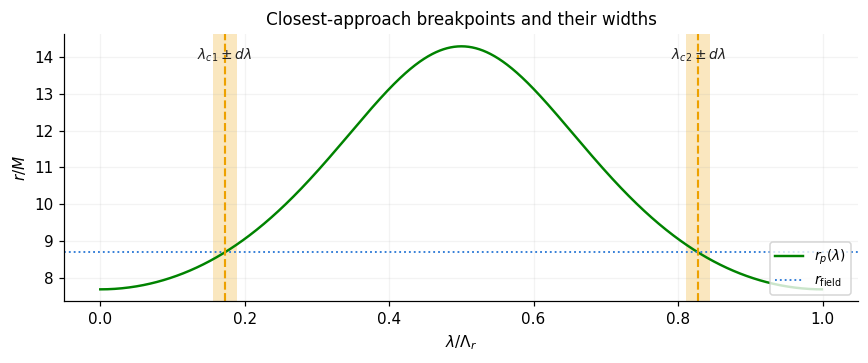

In [8]:
def lambda_from_psi(psiC):
    '''Bisection on monotonic psi(lambda) over [0, Vr/2] (insp_lambda_from_psi).'''
    lo, hi = 0.0, 0.5*Vr
    if psiC <= 0.0:
        return lo
    if psiC >= np.pi:
        return hi
    for _ in range(120):
        mid = 0.5*(lo + hi)
        if kg.korb_psifromla(mid, orbit) < psiC:
            lo = mid
        else:
            hi = mid
        if hi - lo <= 4.0*np.finfo(float).eps*Vr:
            break
    return 0.5*(lo + hi)

def chord_dist(r_f, th_f, lam):
    # defined for fixed th_p = pi/2
    rp = r_from_lam(lam)
    s = rp*rp + r_f*r_f - 2.0*rp*r_f*np.sin(th_f)
    return np.sqrt(max(s, 0.0))

def peak_scale(r_f, th_f, lamC):
    '''Offset at which the chord distance doubles (insp_peak_lambda_scale).'''
    d0 = chord_dist(r_f, th_f, lamC)
    if d0 <= 0.0:
        return 0.0
    dl = 1e-9*Vr
    while dl < 0.25*Vr:
        if (chord_dist(r_f, th_f, lamC + dl) >= 2.0*d0 or
                chord_dist(r_f, th_f, lamC - dl) >= 2.0*d0):
            return dl
        dl *= 2.0
    return 0.25*Vr

def find_peaks(r_f, th_f):
    '''Closest-approach breakpoints + widths (insp_panel_find_peaks).'''
    cosPsi = (p/r_f - 1.0)/e
    if cosPsi >= 1.0:
        lamB = [0.0]
    elif cosPsi <= -1.0:
        lamB = [0.5*Vr]
    else:
        lam1 = lambda_from_psi(np.arccos(cosPsi))
        lamB = [lam1, Vr - lam1] if (Vr - 2*lam1) > 1e-12*Vr else [lam1]
    return np.array(lamB), np.array([peak_scale(r_f, th_f, l) for l in lamB])

lamB_py, dlam_py = find_peaks(r_near, th_near)
lamB_out, dlam_out = find_peaks(r_out, np.pi/2)
R_c32 = build_nodes_c(M, 32, r_near, th_near)     # C truth for comparison
print('near point:  python lamB =', lamB_py, ' dlam =', dlam_py)
print('             C      lamB =', R_c32['lamBreak'], ' dlam =', R_c32['dlam'])
print('out  point:  python lamB =', lamB_out, ' dlam =', dlam_out)
assert np.allclose(lamB_py, R_c32['lamBreak'], rtol=0, atol=1e-12*Vr)
assert np.allclose(dlam_py, R_c32['dlam'], rtol=1e-12, atol=0)

fig, ax = plt.subplots(figsize=(8.0, 3.4))
ax.plot(lam_d/Vr, r_d, color=GREEN, lw=1.6, label=r'$r_p(\lambda)$')
ax.axhline(r_near, color=BLUE, lw=1.2, ls=':', label=r'$r_{\rm field}$')
for k, (lc, dl) in enumerate(zip(lamB_py, dlam_py)):
    ax.axvline(lc/Vr, color=YELLOW, lw=1.4, ls='--')
    ax.axvspan((lc-dl)/Vr, (lc+dl)/Vr, color=YELLOW, alpha=0.25, lw=0)
    ax.annotate(f'$\\lambda_{{c{k+1}}}\\pm d\\lambda$', (lc/Vr, rmax-0.35),
                color=INK, fontsize=9, ha='center')
ax.set_xlabel(r'$\lambda/\Lambda_r$'); ax.set_ylabel(r'$r/M$')
ax.set_title('Closest-approach breakpoints and their widths', fontsize=11)
ax.legend(loc='lower right', fontsize=9)
plt.tight_layout()

## 4. Ingredient 2: the geometric panel stack

Between consecutive breakpoints the integrand is smooth, so the domain is
split into segments with peaks only at segment *ends* (the period is unwrapped
to $[\lambda_{c1},\, \lambda_{c1}+\Lambda_r]$ to guarantee this). Toward each
end, panel widths **halve** until the innermost sliver is no wider than the
peak's own scale $d\lambda$:

$$K = \Big\lceil \log_2 \frac{h}{d\lambda} \Big\rceil \quad
  (\text{capped at } \texttt{maxLevels}),$$

with $h$ the segment half-width. A near-singularity whose variation scale is
$d\lambda$ is thus resolved with $O(\log(h/d\lambda))$ panels instead of the
$O(h/d\lambda)$ a uniform grid needs. 
At an exact crossing ($d\lambda = 0$) the stack runs to the
`maxLevels` floor: the un-resolved core then contributes at relative level
$\sim 2^{-K}$ of the period.

22 geometric panels; width range [2.41e-02, 3.85e-01]


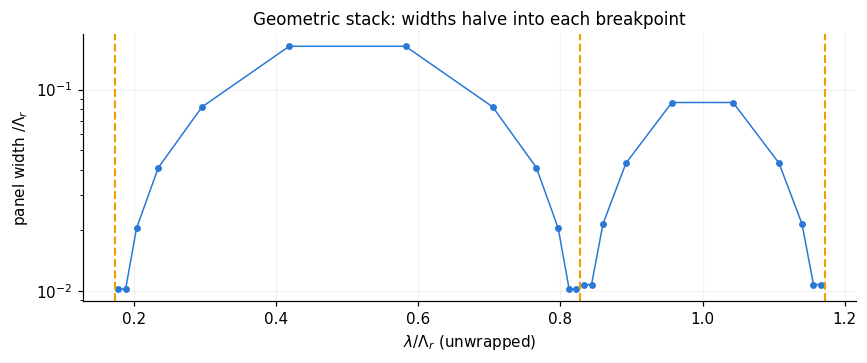

In [9]:
def panel_levels(h, dlamPeak, maxLevels):
    if dlamPeak >= h:
        return 0
    if dlamPeak <= 0.0:
        return maxLevels
    return min(max(int(np.ceil(np.log2(h/dlamPeak))), 0), maxLevels)

def geo_edges(lamB, dlam, maxLevels=40):
    '''Geometric panel edges over the unwrapped period (build steps 1-2).'''
    nB = len(lamB)
    if nB == 1:
        segs = [(lamB[0], lamB[0] + Vr, dlam[0], dlam[0])]
    else:
        segs = [(lamB[0], lamB[1], dlam[0], dlam[1]),
                (lamB[1], lamB[0] + Vr, dlam[1], dlam[0])]
    ga, gb = [], []
    for A, B, dA, dB in segs:
        h = 0.5*(B - A)
        KA = panel_levels(h, dA, maxLevels)
        KB = panel_levels(h, dB, maxLevels)
        ga.append(A); gb.append(A + h*2.0**-KA)          # innermost sliver at A
        for k in range(KA, 0, -1):                       # growing toward mid
            ga.append(A + h*2.0**-k); gb.append(A + h*2.0**-(k-1))
        for k in range(1, KB+1):                         # shrinking toward B
            ga.append(B - h*2.0**-(k-1)); gb.append(B - h*2.0**-k)
        ga.append(B - h*2.0**-KB); gb.append(B)          # innermost sliver at B
    return np.array(ga), np.array(gb)

ga, gb = geo_edges(lamB_py, dlam_py)
print(f'{len(ga)} geometric panels; width range '
      f'[{(gb-ga).min():.2e}, {(gb-ga).max():.2e}]')

fig, ax = plt.subplots(figsize=(8.0, 3.4))
mid = 0.5*(ga + gb)
ax.semilogy(mid/Vr, (gb - ga)/Vr, 'o-', color=BLUE, lw=1.0, ms=3.5)
for lc in lamB_py:
    for off in (0.0, Vr):
        xx = (lc + off)/Vr
        if lamB_py[0]/Vr - 1e-9 <= xx <= lamB_py[0]/Vr + 1 + 1e-9:
            ax.axvline(xx, color=YELLOW, lw=1.4, ls='--')
ax.set_xlabel(r'$\lambda/\Lambda_r$ (unwrapped)')
ax.set_ylabel(r'panel width $/\Lambda_r$')
ax.set_title('Geometric stack: widths halve into each breakpoint', fontsize=11)
plt.tight_layout()

## 5. Ingredient 3: oscillation subdivision

The stack handles the peak but not the carrier, and a $q$-point Gauss–Legendre
rule integrates $e^{i\omega t}$ accurately only while
$\omega\,\Delta t \lesssim q$. Since the node set must serve every requested
$n$, each geometric panel is split uniformly until the **highest** requested
frequency

$$\omega_{\max} = |m|\,\Omega_\phi + n_{\max}\,\Omega_r$$

satisfies that bound: $n_s = \lceil \omega_{\max}\Delta t / q\rceil$ subpanels,
with $\Delta t = \Delta\lambda \cdot (dt/d\lambda)|_{\rm mid}$. This causes the 
node count to grow *linearly* in $n_{\max}$ (the wide mid-segment panels split), while the
geometric stack is $n$-independent and depends only on the orbit.

 nMax  python N     C N
    0       352     352
    8       384     384
   32       480     480
  128       992     992


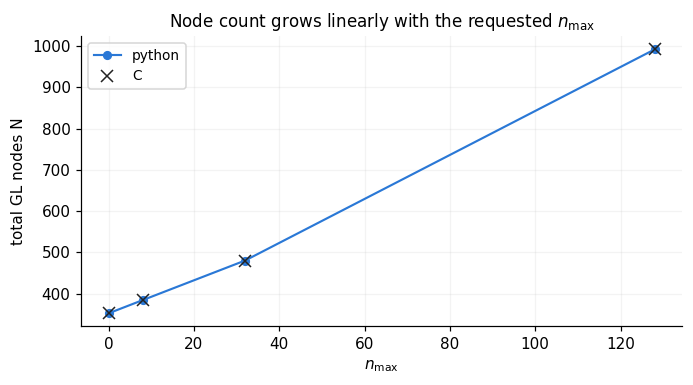

In [10]:
def subdivide(ga, gb, m, nMax, order):
    '''Uniform oscillation split of each geometric panel (build step 3).'''
    omegaMax = abs(m)*abs(om_ph) + max(nMax, 0)*abs(om_r)
    pa, pb = [], []
    for A, B in zip(ga, gb):
        Jmid = dtdlam(math.fmod(0.5*(A + B), Vr))
        dt = (B - A)*Jmid
        ns = max(int(np.ceil(omegaMax*dt/order)), 1) if omegaMax > 0 else 1
        w = (B - A)/ns
        for k in range(ns):
            pa.append(A + k*w)
            pb.append(B if k == ns-1 else A + (k+1)*w)
    return np.array(pa), np.array(pb)

order = 16
print(f'{"nMax":>5s} {"python N":>9s} {"C N":>7s}')
counts_py, counts_c, nmaxes = [], [], (0, 8, 32, 128)
for nMax in nmaxes:
    pa, pb = subdivide(ga, gb, M, nMax, order)
    Npy = order*len(pa)
    Rc = build_nodes_c(M, nMax, r_near, th_near)
    counts_py.append(Npy); counts_c.append(Rc['N'])
    print(f'{nMax:5d} {Npy:9d} {Rc["N"]:7d}')
    c.panel_nodes_free(Rc['_s'])
assert counts_py == counts_c, 'python panel subdivision differs from C'

fig, ax = plt.subplots(figsize=(6.4, 3.6))
ax.plot(nmaxes, counts_py, 'o-', color=BLUE, lw=1.4, ms=5, label='python')
ax.plot(nmaxes, counts_c, 'x', color=INK, ms=8, label='C')
ax.set_xlabel(r'$n_{\max}$'); ax.set_ylabel('total GL nodes N')
ax.set_title('Node count grows linearly with the requested '
             r'$n_{\max}$', fontsize=11)
ax.legend(fontsize=9)
plt.tight_layout()

## 6. Ingredient 4: assembly

Given a panel, an `order`-point Gauss–Legendre rule supplies nodes
$\lambda_j$ and weights $w_j$. Each node gets one (expensive) evaluation of
all six m-mode components, plus the Jacobian $J = dt/d\lambda$ and
carrier time $t(\lambda)$. Nodes past
the period wrap ($\lambda \ge \Lambda_r$) are folded to $\lambda - \Lambda_r$
for **both** the source sample *and* the carrier time. The full integrand
$e^{i\omega_{mn}t} X_m(t)$ is exactly $T_r$-periodic (the m-carrier cancels
the secular phase of $X_m$), but $X_m$ alone is not, and continuing $t$ by $T_r$
while folding only the sample would tag wrapped nodes with a spurious
$e^{i m\Omega_\phi T_r}$ factor.

Every $n$ is then a weighted phase sum over the *same* stored samples:

$$X_n = \frac{1}{T_r} \sum_k w_k\, J_k\, X_m(\lambda_k)\,
        e^{i\omega_{mn} t_k}.$$

In [11]:
def build_nodes_py(m, nMax, r_f, th_f, order=16, max_levels=40):
    '''Pure-Python replica of inspectre_panel_nodes_build.'''
    lamB, dlam = find_peaks(r_f, th_f)
    ga_, gb_ = geo_edges(lamB, dlam, max_levels)
    pa, pb = subdivide(ga_, gb_, m, nMax, order)
    
    # get the Legendre-Gauss notes and weights
    xi_, wq_ = np.polynomial.legendre.leggauss(order)
    lam = (0.5*(pa + pb)[:, None] + 0.5*(pb - pa)[:, None]*xi_).ravel()
    w = (0.5*(pb - pa)[:, None]*wq_ + 0.0*xi_).ravel()
    lamE = np.where(lam >= Vr, lam - Vr, lam)         # the wrap fold
    t = np.array([t_from_lam(l) for l in lamE])
    J = np.array([dtdlam(l) for l in lamE])
    vals = np.array([eval6(m, l, r_f, th_f) for l in lamE])   # (N, 6)
    bad = ~np.isfinite(vals)
    nNonFinite = int(bad.sum())
    if nNonFinite:
        vals[bad] = 0.0            # same zero-and-count policy as the C code
    return dict(lam=lam, w=w, t=t, J=J, vals=vals, N=len(lam),
                order=order, lamBreak=lamB, dlam=dlam,
                nNonFinite=nNonFinite)

def integrate_py(R, m, n):
    '''X_n for all 6 components from a stored node set.'''
    ph = np.exp(1j*(m*om_ph + n*om_r)*R['t'])
    W = R['w']*R['J']*ph
    return (W[:, None]*R['vals']).sum(axis=0)/Tr

n_list = [0, 4, 8, 32]
t0 = time.perf_counter()
P_near = build_nodes_py(M, max(n_list), r_near, th_near)
t_build_py = time.perf_counter() - t0
X_py_near = {n_: integrate_py(P_near, M, n_) for n_ in n_list}
P_out = build_nodes_py(M, max(n_list), r_out, np.pi/2)
X_py_out = {n_: integrate_py(P_out, M, n_) for n_ in n_list}

print(f'near point: N={P_near["N"]} nodes, build {t_build_py:.1f} s, '
      f'nNonFinite={P_near["nNonFinite"]}')
print(f'\n{"n":>3s}  {"PhiS":>28s}  {"src":>28s}')
for n_ in n_list:
    v = X_py_near[n_]
    print(f'{n_:3d}  {v[0]:+.6e}  {v[5]:+.6e}')

near point: N=480 nodes, build 2.7 s, nNonFinite=0

  n                          PhiS                           src
  0  +1.008451e-01+5.973505e-17j  +3.088531e-06+6.368639e-15j
  4  +2.567869e-02-8.081280e-17j  +8.155289e-05-6.913395e-15j
  8  -1.613377e-02+4.300791e-17j  -1.370875e-04+4.239361e-15j
 32  +1.168752e-03-9.054355e-17j  +1.326017e-04-4.797014e-15j


## 7. Validation against the C implementation

Three levels:
1. **node-for-node** — same breakpoints, panel edges, weights and Jacobians as
   `panel_nodes_build` (differences at machine rounding only, GSL's GL table
   vs numpy's `leggauss`);
2. **value-for-value** — the assembled $X_n$ against `panel_nodes_integrate`
   for every component and every $n$ (same nodes, same weights $\Rightarrow$
   roundoff-level agreement);
3. **truth** — both against the adaptive QAG_MINO reference at the
   `test_panel_gl.py` criterion (rel $<10^{-6}$ or abs $<10^{-12}$).

In [12]:
# --- level 1: node-for-node -------------------------------------------
R_c = build_nodes_c(M, max(n_list), r_near, th_near)
assert P_near['N'] == R_c['N'], (P_near['N'], R_c['N'])
i_py, i_c = np.argsort(P_near['lam']), np.argsort(R_c['lam'])
dlam_nodes = np.abs(P_near['lam'][i_py] - R_c['lam'][i_c]).max()
dw = np.abs((P_near['w']*P_near['J'])[i_py] - (R_c['w']*R_c['J'])[i_c]).max()
dt_nodes = np.abs(P_near['t'][i_py] - R_c['t'][i_c]).max()
print(f'node count           : {P_near["N"]} (both)')
print(f'max |dlam| / Vr      : {dlam_nodes/Vr:.2e}')
print(f'max |d(w*J)|         : {dw:.2e}')
print(f'max |dt|             : {dt_nodes:.2e}')
assert dlam_nodes < 1e-12*Vr and dt_nodes < 1e-9

# --- level 2: value-for-value -----------------------------------------
R_co = build_nodes_c(M, max(n_list), r_out, np.pi/2)
def nullsafe_rel(A, B):
    '''Relative diff, except components below the 1e-13 null floor (dead
    modes, e.g. high n at the out point) are compared absolutely.'''
    d = np.abs(A - B)
    return np.where(np.abs(B) < 1e-13, d, d/np.maximum(np.abs(B), 1e-300))

print(f'\npython vs C, max over 6 components (null-safe rel):')
print(f'{"n":>3s} {"near":>10s} {"out":>10s}')
worst = 0.0
for n_ in n_list:
    d_near = nullsafe_rel(X_py_near[n_], integrate_c(R_c, M, n_))
    d_out = nullsafe_rel(X_py_out[n_], integrate_c(R_co, M, n_))
    worst = max(worst, d_near.max(), d_out.max())
    print(f'{n_:3d} {d_near.max():10.2e} {d_out.max():10.2e}')
assert worst < 1e-10, f'python/C disagreement {worst:.2e}'
print(f'\nworst: {worst:.2e}  -> same rule, roundoff only')

node count           : 480 (both)
max |dlam| / Vr      : 0.00e+00
max |d(w*J)|         : 4.88e-15
max |dt|             : 0.00e+00

python vs C, max over 6 components (null-safe rel):
  n       near        out
  0   1.50e-14   6.41e-16
  4   7.52e-16   7.67e-15
  8   8.89e-16   2.45e-12
 32   1.01e-14   2.87e-18

worst: 2.45e-12  -> same rule, roundoff only


In [13]:
# --- level 3: both vs the adaptive QAG_MINO truth ---------------------
print(f'{"pt":>5s} {"n":>3s} {"comp":>8s} {"python rel":>11s} {"C rel":>11s}')
fails = 0
for tag, Xpy, Rc_ in (('near', X_py_near, R_c), ('out', X_py_out, R_co)):
    for n_ in (0, 8):
        ref = REF[tag, n_]
        vc = integrate_c(Rc_, M, n_)
        for ci in (0, 2, 5):            # PhiS, dPhiS_r, src
            rp_ = abs(Xpy[n_][ci] - ref[ci])
            rc_ = abs(vc[ci] - ref[ci])
            sp = rp_/max(abs(ref[ci]), 1e-300)
            sc = rc_/max(abs(ref[ci]), 1e-300)
            okp = sp < 1e-6 or rp_ < 1e-12
            okc = sc < 1e-6 or rc_ < 1e-12
            fails += (not okp) + (not okc)
            print(f'{tag:>5s} {n_:3d} {COMP[ci]:>8s} {sp:11.2e} {sc:11.2e}'
                  + ('' if okp and okc else '   <-- FAIL'))
assert fails == 0, f'{fails} components outside the test_panel_gl criterion'
print('\nall components within the test_panel_gl criterion '
      '(rel < 1e-6 or abs < 1e-12)')

   pt   n     comp  python rel       C rel
 near   0     PhiS    1.04e-15    1.51e-15
 near   0  dPhiS_r    2.86e-14    2.83e-14
 near   0      src    1.41e-08    1.41e-08
 near   8     PhiS    1.02e-14    1.09e-14
 near   8  dPhiS_r    1.66e-14    1.63e-14
 near   8      src    2.81e-10    2.81e-10
  out   0     PhiS    3.18e-16    1.60e-16
  out   0  dPhiS_r    4.51e-15    3.89e-15
  out   0      src    9.07e-12    9.07e-12
  out   8     PhiS    1.28e-11    1.28e-11
  out   8  dPhiS_r    3.22e-11    3.08e-11
  out   8      src    5.73e-11    5.73e-11

all components within the test_panel_gl criterion (rel < 1e-6 or abs < 1e-12)


In [14]:
# --- cost: python loop vs C build -------------------------------------
t0 = time.perf_counter()
R_t = build_nodes_c(M, max(n_list), r_near, th_near)
t_build_c = time.perf_counter() - t0
c.panel_nodes_free(R_t['_s'])
t0 = time.perf_counter()
for n_ in n_list:
    integrate_c(R_c, M, n_)
t_int_c = (time.perf_counter() - t0)/len(n_list)
t0 = time.perf_counter()
for n_ in n_list:
    integrate_py(P_near, M, n_)
t_int_py = (time.perf_counter() - t0)/len(n_list)
print(f'node-set build ({P_near["N"]} nodes):  '
      f'python {t_build_py:5.2f} s   C {t_build_c:5.2f} s')
print(f'per-n integrate (6 comps):  '
      f'python {t_int_py*1e6:5.0f} us   C {t_int_c*1e6:5.0f} us')
print(f'\nBuild cost is dominated by the effective-source evaluation at each '
      f'node,\nwhich python and C share -- the pure-Python scaffolding adds '
      f'almost nothing.\nThe per-n reuse is the economy: ~{t_build_c/t_int_c:,.0f}x '
      f'cheaper than a fresh build,\nand ~1000x cheaper than one adaptive '
      f'QAG_MINO solve per n.')
for R_ in (R_c, R_co):
    c.panel_nodes_free(R_['_s'])

node-set build (480 nodes):  python  2.70 s   C  2.70 s
per-n integrate (6 comps):  python   104 us   C    94 us

Build cost is dominated by the effective-source evaluation at each node,
which python and C share -- the pure-Python scaffolding adds almost nothing.
The per-n reuse is the economy: ~28,730x cheaper than a fresh build,
and ~1000x cheaper than one adaptive QAG_MINO solve per n.
